# EDA и бинарная классификация на датасете «Титаник»

**Дисциплина:** Машинное обучение и ИИ  
**Модуль 1:** Введение в Data Science и EDA  
**Датасет:** Titanic  

**Выполнил:** Емельянова Ксения Павловна  
**Группа:** ПКТб-23-1  
**Преподаватель:** Спирин Игорь Сергеевич  

**Ссылка на репозиторий:** https://github.com/fivifri/ml-course-emelyanova  
**Путь к модулю:** `module-1-titanic/notebook.ipynb`  
**Дата сдачи:** 2026-28-09

## Введение

**Задача:** бинарная классификация — предсказать, выжил ли пассажир Titanic (0 — не выжил, 1 — выжил).

**Что такое ML-проект:** ML-проект — это полный жизненный цикл создания интеллектуального решения, который начинается с анализа бизнеса и сбора данных, продолжается их подготовкой, EDA и созданием признаков, а завершается обучением, подбором моделей, их оценкой и внедрением. Это итеративный процесс, где результаты оценки часто заставляют возвращаться к начальным этапам для улучшения качества.

**Почему классификация, а не регрессия:** Целевая переменная является дискретной и принимает значения из ограниченного множества классов (выжил / не выжил), а не непрерывным числовым значением (как, например, цена квартиры или температура). Регрессия предсказывает непрерывную величину, тогда как классификация разделяет объекты по категориям.

**Какая метрика важнее:** В этой задаче наиболее информативной метрикой является **ROC-AUC**, так как она оценивает способность модели ранжировать пассажиров по вероятности выживания независимо от выбранного порога классификации и устойчива к возможному дисбалансу классов. Для оценки качества на фиксированном пороге лучше использовать **F1-score**, поскольку она гармонично объединяет точность (Precision) и полноту (Recall), в отличие от Accuracy, которая может давать обманчиво высокий результат при дисбалансе.

**Цель работы:**
1. Провести полный EDA датасета Титаник.
2. Обучить 2+ модели и достичь ROC-AUC ≥ 0.80.
3. Реализовать функцию предсказания для нового пассажира.

## Теоретический обзор ключевых понятий ML

### 1. EDA (Exploratory Data Analysis)
Разведочный анализ данных (EDA) — это первичный этап исследования датасета, направленный на понимание его структуры, природы и внутренних закономерностей. Он необходим для того, чтобы увидеть «полную картину» данных до того, как подавать их в алгоритмы машинного обучения. В процессе EDA исследователь проверяет типы данных, находит пропуски, выявляет аномалии и выбросы, а также изучает распределения признаков. Кроме того, на этом этапе анализируются корреляции между фичами и целевой переменной, что помогает сформировать гипотезы для дальнейшей предобработки. Без качественного EDA высок риск обучить модель на нерелевантной или искаженной информации.

---

### 2. Пропуски (NaN)
Пропущенные значения возникают по разным причинам: от сбоев при сборе и записи данных до нежелания пользователей заполнять необязательные поля анкеты. Обработка пропусков критически важна, так как большинство классических ML-моделей не умеют работать с `NaN` напрямую. Выбор стратегии зависит от природы данных: строки или столбцы с большим количеством пропусков можно просто удалить, если это не приведет к потере важной информации. В остальных случаях применяют импутацию — заполнение пропусков медианой или средним значением для числовых признаков, либо модой для категориальных. Для сложных взаимосвязей также используют заполнение с помощью моделей (например, KNN) или выделение факта отсутствия значения в отдельный бинарный признак-индикатор.

---

### 3. Кодирование категориальных признаков
Категориальные переменные содержат текстовые метки или группы, которые необходимо перевести в числовой формат для восприятия алгоритмами. При **Label Encoding** каждой уникальной категории присваивается целое число (0, 1, 2...), однако этот метод может создать ложное представление об иерархии или порядке категорий там, где его нет. В свою очередь, **One-Hot Encoding** преобразует одну категориальную колонку в $N$ бинарных столбцов (0 или 1), где $N$ — количество уникальных значений. One-Hot идеален для нелинейных категорий, но может сильно раздуть размерность датасета при высоком кардинале признака.

---

### 4. Масштабирование признаков
Масштабирование необходимо для того, чтобы признаки с большими значениями (например, доход или цена) не перевешивали признаки с малыми значениями (например, возраст) в моделях, чувствительных к расстояниям и градиентным спускам. **StandardScaler** примет распределение признака к нулевому среднему и единичному стандартному отклонению ($\mu = 0, \sigma = 1$), что отлично подходит для данных с нормальным распределением. **MinMaxScaler** сжимает значения в строго заданный диапазон (обычно от 0 до 1), сохраняя исходное распределение. Выбор зависит от алгоритма: линейным моделям и KNN масштабирование жизненно необходимо, тогда как решающие деревья устойчивы к разнице в масштабах.

---

### 5. Feature Engineering
Feature Engineering — это процесс создания новых признаков на основе имеющихся данных для повышения прогностической силы модели. Нативные данные не всегда напрямую отражают скрытые физические или логические связи, поэтому инженерная разработка признаков помогает подсветить их для алгоритма. Например, из даты рождения можно выделить чистый возраст, из адреса — объединить улицы в районы, а из размера семьи — создать бинарный флаг «путешествует один». Качественный Feature Engineering часто дает больший прирост к качеству модели, чем подбор гиперпараметров самого алгоритма.

---

### 6. Метрики классификации
Метрики необходимы для объективной оценки качества работы классификатора с разных точек зрения. **Accuracy** показывает общую долю правильных ответов, но может быть обманчивой при сильном дисбалансе классов. **Precision** (точность) измеряет, какая доля объектов, названных моделью положительными, реально таковыми является, а **Recall** (полнота) показывает, какую долю реальных положительных объектов модель смогла найти. Для балансировки между точностью и полнотой используется **F1-score**, представляющая собой их гармоническое среднее. Метрика **ROC-AUC** оценивает способность модели ранжировать объекты по вероятности принадлежности к классу, рассчитываясь как площадь под кривой соотношения True Positive Rate и False Positive Rate при различных порогах классификации.

**Основные формулы метрик:**

$$Accuracy = \frac{TP + TN}{TP + TN + FP + FN}$$

$$Precision = \frac{TP}{TP + FP} \quad \quad Recall = \frac{TP}{TP + FN}$$

$$F1 = 2 \cdot \frac{Precision \cdot Recall}{Precision + Recall}$$

---

### Сравнительный обзор методов и подходов

| Понятие / Инструмент | Основное назначение | Преимущества | Ограничения / Риски |
| :--- | :--- | :--- | :--- |
| **EDA** | Исследование структуры и закономерностей датасета | Выявляет ошибки, выбросы и скрытые паттерны на раннем этапе | Требует времени и глубокого погружения в предметную область |
| **Label Encoding** | Перевод категорий в целые числа (0, 1, 2...) | Компактность, не увеличивает количество столбцов | Может навязать модели ложный порядок/приоритет категорий |
| **One-Hot Encoding** | Создание $N$ бинарных колонок для $N$ категорий | Не навязывает порядок категорий | Проблема «проклятия размерности» при многих уникальных значениях |
| **StandardScaler** | Приведение данных к $\mu = 0, \sigma = 1$ | Эффективен для линейных моделей и алгоритмов с градиентным спуском | Чувствителен к сильным выбросам |
| **MinMaxScaler** | Сжатие данных в строго заданный интервал $[0, 1]$ | Сохраняет исходную форму распределения и нулевые значения | Стягивает основные данные в узкий диапазон при наличии выбросов |

In [3]:
import pandas as pd

# Загрузка датасета Titanic (train и test)
train_df = pd.read_csv('./module-1-titanic/data/train.csv')
test_df = pd.read_csv('./module-1-titanic/data/test.csv')

# Вывод размеров обучающей и тестовой выборок
print(train_df.shape, test_df.shape)

(891, 12) (418, 11)


## Описание данных

**Источник:** [Kaggle Titanic: Machine Learning from Disaster](https://www.kaggle.com/c/titanic)

**Структура:**
- Всего примеров в train: 891
- Всего примеров в test: 418
- Признаков: 11 (+ целевая `Survived`)
- Числовых признаков: 6 (`PassengerId`, `Pclass`, `Age`, `SibSp`, `Parch`, `Fare`)
- Категориальных признаков: 5 (`Name`, `Sex`, `Ticket`, `Cabin`, `Embarked`)

**Описание столбцов:**
| Столбец | Тип | Описание | Пропуски |
|---------|-----|----------|----------|
| PassengerId | int64 | Уникальный ID пассажира | 0% |
| Survived | int64 (0/1) | Целевая переменная: выжил (1) или погиб (0) | 0% |
| Pclass | int64 (1/2/3) | Класс билета (1 = 1-й, 2 = 2-й, 3 = 3-й) | 0% |
| Name | object | Имя и титул пассажира | 0% |
| Sex | object | Пол пассажира (male / female) | 0% |
| Age | float64 | Возраст пассажира в годах | 19.87% |
| SibSp | int64 | Количество братьев/сестер/супругов на борту | 0% |
| Parch | int64 | Количество родителей/детей на борту | 0% |
| Ticket | object | Номер билета | 0% |
| Fare | float64 | Стоимость билета (тариф) | 0% |
| Cabin | object | Номер каюты | 77.10% |
| Embarked | object | Порт посадки (C = Cherbourg, Q = Queenstown, S = Southampton) | 0.22% |

**Распределение классов:**
- Не выжило (0): 549 (61.6%)
- Выжило (1): 342 (38.4%)

**Файл данных в репозитории:** `module-1-titanic/data/titanic_info.md`

## Подготовка данных и EDA

In [6]:
# Импорт необходимых библиотек для работы с данными и визуализации
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder

# Настройка стилей отображения графиков
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['font.size'] = 11

# 1. Загрузка обучающего и тестового датасетов по относительным путям
train_df = pd.read_csv('module-1-titanic/data/train.csv')  # Загрузка обучающей выборки
test_df = pd.read_csv('module-1-titanic/data/test.csv')    # Загрузка тестовой выборки

# 2. Вывод размера выборок
print("=== Размеры выборок ===")
print(f"Train shape: {train_df.shape}")
print(f"Test shape:  {test_df.shape}\n")

# 3. Вывод первых 5 строк обучающего датасета
print("=== Первые 5 строк train_df ===")
print(train_df.head(), "\n")

# 4. Общая информация о типах данных и пропусках
print("=== Информация о датасете (info) ===")
train_df.info()
print("\n")

# 5. Описательная статистика для числовых признаков
print("=== Статистическое описание (describe) ===")
print(train_df.describe(), "\n")

# 6. Анализ пропущенных значений
print("=== Анализ пропусков ===")
missing_count = train_df.isnull().sum() # Подсчет количества пропусков в каждом столбце
missing_pct = (missing_count / len(train_df)) * 100 # Вычисление процента пропусков
missing_table = pd.DataFrame({
    'Количество NaN': missing_count,
    'Процент NaN (%)': missing_pct.round(2)
})
print(missing_table[missing_table['Количество NaN'] > 0], "\n")

# 7. Статистический анализ распределений: Скошенность (Skewness) и Эксцесс (Kurtosis)
numeric_cols = train_df.select_dtypes(include=[np.number]).columns # Выбор только числовых колонок
stats_df = pd.DataFrame({
    'Skewness (Асимметрия)': train_df[numeric_cols].skew().round(3),
    'Kurtosis (Эксцесс)': train_df[numeric_cols].kurtosis().round(3)
})
print("=== Оценка формы распределения числовых признаков ===")
print(stats_df, "\n")

# 8. Анализ распределения целевой переменной Survived
print("=== Распределение целевой переменной Survived ===")
print(train_df['Survived'].value_counts(normalize=True).map(lambda x: f"{x:.2%}"))

=== Размеры выборок ===
Train shape: (891, 12)
Test shape:  (418, 11)

=== Первые 5 строк train_df ===
   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3    

/tmp/ipykernel_924/2311426583.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=train_df, x='Survived', ax=axes[0, 0], palette='Set2')
/tmp/ipykernel_924/2311426583.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0, 0].set_xticklabels(['Не выжил (0)', 'Выжил (1)'])
/tmp/ipykernel_924/2311426583.py:30: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(data=train_df, x='Pclass', y='Survived', hue='Sex', ax=axes[1, 1], palette='Accent', ci=None)
/tmp/ipykernel_924/2311426583.py:36: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(data=train_df, x='Embarked', y='Survived', ax=axes[1, 2], palette='Pastel1', ci=None)
/tmp/ipykern

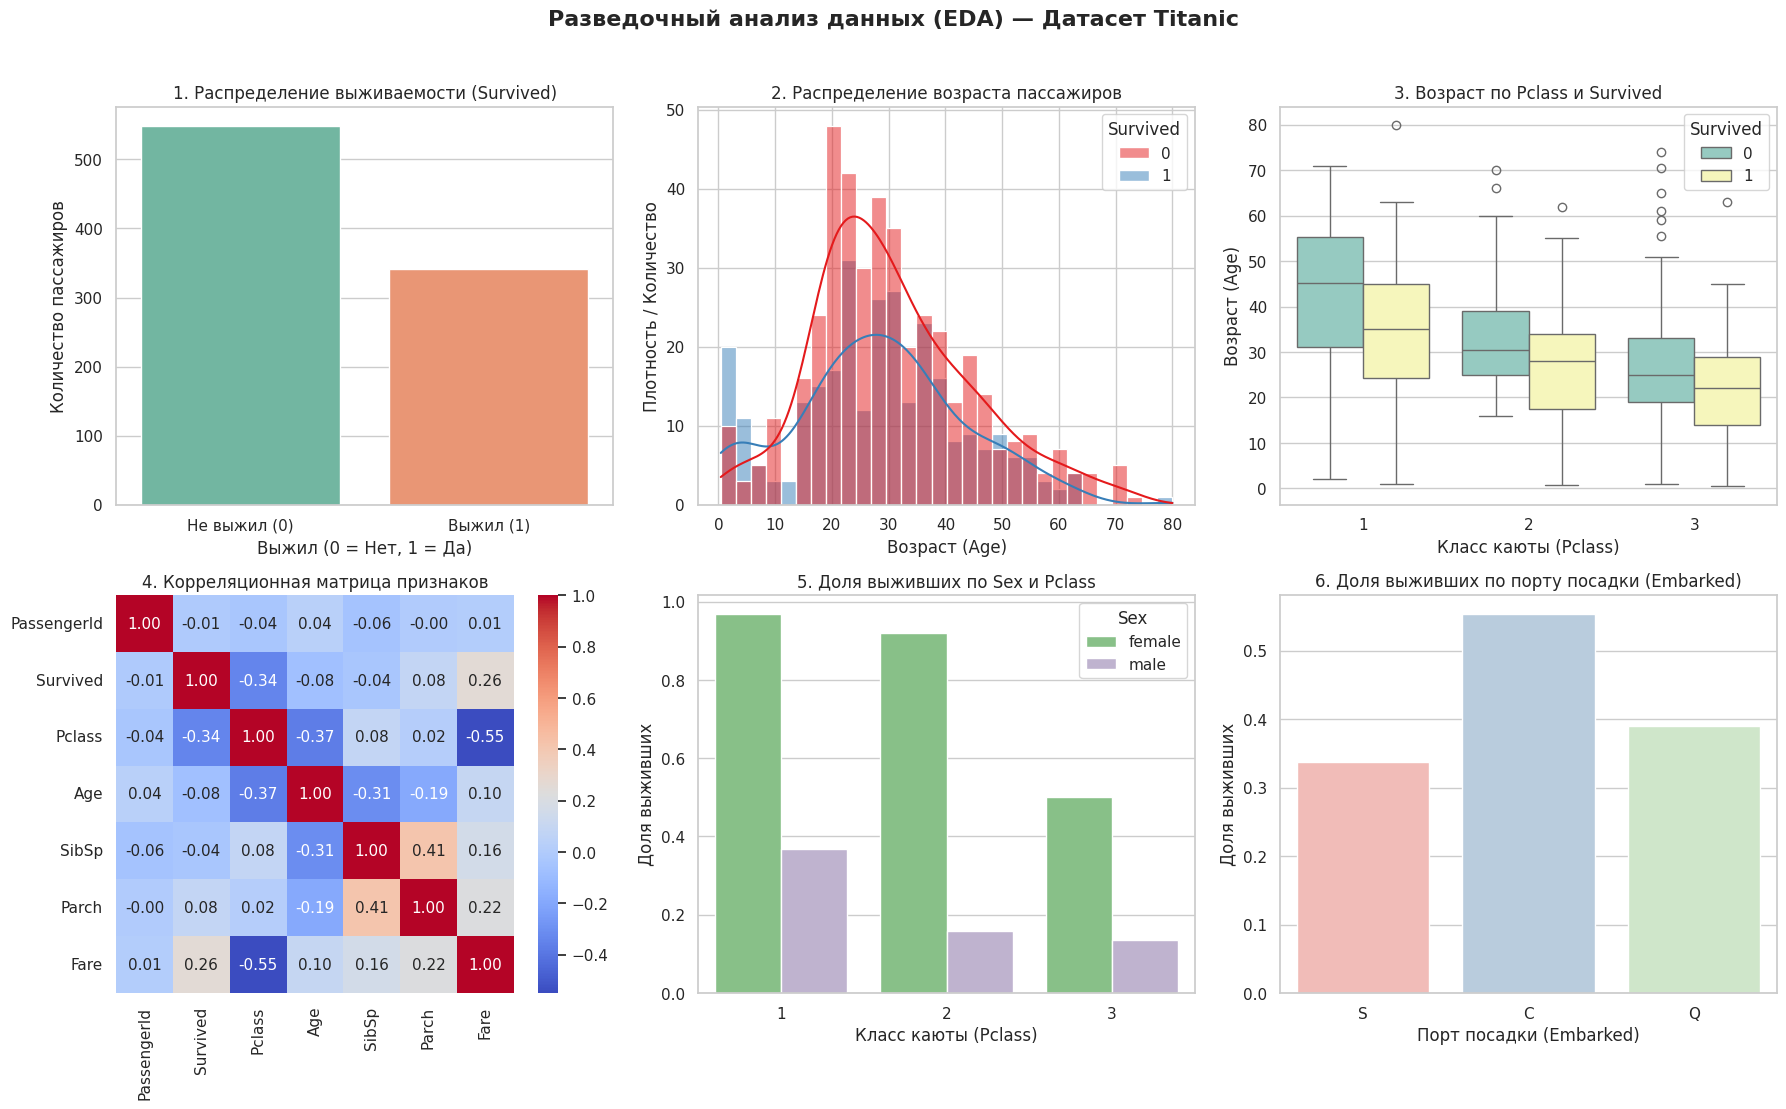

In [7]:
# Создание фигуры и сетки графиков 2х3
fig, axes = plt.subplots(2, 3, figsize=(18, 11))
fig.suptitle('Разведочный анализ данных (EDA) — Датасет Titanic', fontsize=16, fontweight='bold')

# График 1: Countplot — Распределение целевой переменной Survived
sns.countplot(data=train_df, x='Survived', ax=axes[0, 0], palette='Set2')
axes[0, 0].set_title('1. Распределение выживаемости (Survived)')
axes[0, 0].set_xlabel('Выжил (0 = Нет, 1 = Да)')
axes[0, 0].set_ylabel('Количество пассажиров')
axes[0, 0].set_xticklabels(['Не выжил (0)', 'Выжил (1)'])

# График 2: Histplot — Распределение возраста (Age) с разбиением по Survived
sns.histplot(data=train_df, x='Age', hue='Survived', kde=True, ax=axes[0, 1], palette='Set1', bins=30)
axes[0, 1].set_title('2. Распределение возраста пассажиров')
axes[0, 1].set_xlabel('Возраст (Age)')
axes[0, 1].set_ylabel('Плотность / Количество')

# График 3: Boxplot — Возраст по классам кают (Pclass) и выживаемости (Survived)
sns.boxplot(data=train_df, x='Pclass', y='Age', hue='Survived', ax=axes[0, 2], palette='Set3')
axes[0, 2].set_title('3. Возраст по Pclass и Survived')
axes[0, 2].set_xlabel('Класс каюты (Pclass)')
axes[0, 2].set_ylabel('Возраст (Age)')

# График 4: Heatmap — Корреляционная матрица числовых признаков
numeric_df = train_df.select_dtypes(include=[np.number]) # Извлечение числовых столбцов
sns.heatmap(numeric_df.corr(), annot=True, fmt='.2f', cmap='coolwarm', ax=axes[1, 0], cbar=True, square=True)
axes[1, 0].set_title('4. Корреляционная матрица признаков')

# График 5: Barplot — Доля выживших по полу (Sex) и классу (Pclass)
sns.barplot(data=train_df, x='Pclass', y='Survived', hue='Sex', ax=axes[1, 1], palette='Accent', ci=None)
axes[1, 1].set_title('5. Доля выживших по Sex и Pclass')
axes[1, 1].set_xlabel('Класс каюты (Pclass)')
axes[1, 1].set_ylabel('Доля выживших')

# График 6: Barplot — Доля выживших по порту посадки (Embarked)
sns.barplot(data=train_df, x='Embarked', y='Survived', ax=axes[1, 2], palette='Pastel1', ci=None)
axes[1, 2].set_title('6. Доля выживших по порту посадки (Embarked)')
axes[1, 2].set_xlabel('Порт посадки (Embarked)')
axes[1, 2].set_ylabel('Доля выживших')

# Оптимизация отступов между графиками
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

### Наблюдения по результатам визуализации (EDA)

1. **Дисбаланс целевой переменной (`Survived`):**
   * На графике 1 видно, что большинство пассажиров погибло (~61.6% против ~38.4% выживших). При оценке моделей стоит уделять особое внимание метрикам, устойчивым к дисбалансу (ROC-AUC, F1-score).

2. **Возраст и выживаемость (`Age`):**
   * На гистограмме 2 отчетливо заметен пик выживаемости среди маленьких детей (0–5 лет), что подтверждает исторический принцип эвакуации («дети и женщины в первую очередь»).
   * Медианный возраст погибших выше, чем у выживших.

3. **Связь класса каюты и возраста (`Pclass` vs `Age`):**
   * График 3 демонстрирует, что пассажиры 1-го класса в среднем существенно старше (медиана 37 лет), чем пассажиры 2-го (29 лет) и 3-го классов (24 года). По этой причине заполнять пропуски в возрасте эффективнее медианой с группировкой по классу и полу.

4. **Корреляции (`Heatmap`):**
   * Выживаемость (`Survived`) сильнее всего коррелирует с ценой билета `Fare` ($+0.26$) и обратно коррелирует с классом каюты `Pclass` ($-0.34$).
   * Также наблюдается сильная отрицательная корреляция между `Pclass` и `Fare` ($-0.55$), что логично.

5. **Влияние пола и класса на выживаемость (`Sex` & `Pclass`):**
   * График 5 показывает колоссальную разницу в выживаемости: женщины 1-го и 2-го классов выживали с вероятностью близкой к 90–95%, тогда как у мужчин 3-го класса вероятность выжить была ниже 15–20%.

6. **Порт посадки (`Embarked`):**
   * Самый высокий процент выживших наблюдается у пассажиров, севших в порту `C` (Cherbourg) — более 50%, что связано с высокой долей пассажиров 1-го класса среди севших в этом порту.

### Обоснование стратегии обработки пропущенных значений

| Признак | Процент пропусков | Выбранная стратегия | Подробное обоснование |
| :--- | :--- | :--- | :--- |
| **`Age`** | `~19.87%` (177 строк) | **Заполнение медианой по группам (`Pclass` + `Sex`)** | Распределение возраста не является строго симметричным и имеет скошенность. Кроме того, средний возраст сильно различается в зависимости от класса каюты (в 1-м классе ехали более состоятельные и взрослые люди) и пола. Заполнение групповой медианой сохраняет логическую структуру данных лучше, чем единая общая медиана. |
| **`Embarked`** | `~0.22%` (2 строки) | **Заполнение модой (самым частым значением)** | Пропущено всего 2 значения. Модальным значением является порт `'S'` (Southampton), в котором села подавляющая часть пассажиров (~72%). Заполнение модой не исказит распределение. |
| **`Cabin`** | `~77.10%` (687 строк) | **Удаление столбца** | Более 77% данных отсутствует. Восстановление такого количества значений с помощью алгоритмов с высокой вероятностью приведет к внесению шума и переобучению модели. |

In [8]:
# Создаем копию датасета для выполнения преобразований
df_clean = train_df.copy()

# -------------------------------------------------------------------------
# 1. ОБРАБОТКА ПРОПУСКОВ
# -------------------------------------------------------------------------

# 1.1 Заполнение пропусков в Age медианой по группам (Pclass + Sex)
age_medians = df_clean.groupby(['Pclass', 'Sex'])['Age'].transform('median') # Расчет медиан для каждой группы
df_clean['Age'] = df_clean['Age'].fillna(age_medians)                         # Заполнение NaN рассчитанными медианами

# 1.2 Заполнение пропусков в Embarked модой (самым частым значением)
embarked_mode = df_clean['Embarked'].mode()[0]                                # Нахождение моды
df_clean['Embarked'] = df_clean['Embarked'].fillna(embarked_mode)            # Заполнение пропусков модой

# 1.3 Удаление столбца Cabin из-за критического количества пропусков (>77%)
df_clean = df_clean.drop(columns=['Cabin'])

# Проверка: убеждаемся, что пропусков не осталось
print("=== Проверка остатка пропусков после обработки ===")
print(df_clean.isnull().sum()[df_clean.isnull().sum() > 0]) # Должно быть пусто

# -------------------------------------------------------------------------
# 2. FEATURE ENGINEERING (Создание новых признаков)
# -------------------------------------------------------------------------

# 2.1 Создание размера семьи Family_Size = SibSp + Parch + 1 (сам пассажир)
df_clean['Family_Size'] = df_clean['SibSp'] + df_clean['Parch'] + 1

# 2.2 Создание бинарного признака Is_Alone (1 — путешествует один, 0 — с семьей)
df_clean['Is_Alone'] = (df_clean['Family_Size'] == 1).astype(int)

# 2.3 Биннинг возраста (Age_Group) через pd.cut() на 5 категориальных интервалов
df_clean['Age_Group'] = pd.cut(
    df_clean['Age'],
    bins=[0, 12, 18, 35, 60, 100],
    labels=['Child', 'Teenager', 'Young_Adult', 'Adult', 'Senior']
)

print("\n=== Проверка созданных признаков ===")
print(df_clean[['Family_Size', 'Is_Alone', 'Age_Group']].head())

# -------------------------------------------------------------------------
# 3. КОДИРОВАНИЕ КАТЕГОРИАЛЬНЫХ ПРИЗНАКОВ
# -------------------------------------------------------------------------

# 3.1 Label Encoding для бинарного признака Sex (male/female -> 0/1)
le = LabelEncoder()
df_clean['Sex'] = le.fit_transform(df_clean['Sex']) # male -> 1, female -> 0 (или наоборот)

# 3.2 One-Hot Encoding для номинативного признака Embarked (создание бинарных столбцов)
df_clean = pd.get_dummies(df_clean, columns=['Embarked'], drop_first=False, dtype=int)

# Вывод итоговой структуры обработанного датасета
print("\n=== Итоговые столбцы датасета ===")
print(df_clean.columns.tolist())
print("\nПервые 3 строки итогового датасета:")
print(df_clean.head(3))

=== Проверка остатка пропусков после обработки ===
Series([], dtype: int64)

=== Проверка созданных признаков ===
   Family_Size  Is_Alone    Age_Group
0            2         0  Young_Adult
1            2         0        Adult
2            1         1  Young_Adult
3            2         0  Young_Adult
4            1         1  Young_Adult

=== Итоговые столбцы датасета ===
['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Family_Size', 'Is_Alone', 'Age_Group', 'Embarked_C', 'Embarked_Q', 'Embarked_S']

Первые 3 строки итогового датасета:
   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   

                                                Name  Sex   Age  SibSp  Parch  \
0                            Braund, Mr. Owen Harris    1  22.0      1      0   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...    0  38.0      1      0   
2                   